# Ejercicio 3 — Consultas directas sobre archivos Parquet (2026)

Todas las consultas están en `sql/03_exploracion.sql` y se ejecutan **directamente sobre los archivos Parquet** de `data/raw/`; no se crea ninguna tabla.
La interpretación y las decisiones están en `docs/03_consultas_directas.md`.

In [1]:
import sys
sys.path.insert(0, "../scripts")
import matplotlib.pyplot as plt
import pandas as pd
from sqlrun import conectar, cargar_consultas

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
con = conectar()          # DuckDB en memoria + vistas de sql/00_vistas.sql (sobre Parquet)
q = cargar_consultas("sql/03_exploracion.sql")

def run(nombre):
    c = q[nombre]
    print("Objetivo:", c.meta.get("objetivo"))
    print("Fuente:  ", c.meta.get("fuente"))
    print()
    print(c.sql)
    return con.sql(c.sql).df()

## 3.1 Archivos disponibles

In [2]:
run("archivos_disponibles")

Objetivo: 3.1 Cuantos archivos Parquet hay por tipo de taxi y anio
Fuente:   data/raw/*/2026/*.parquet (listado del sistema de archivos con glob)

SELECT
    split_part(file, '/', 3)                 AS taxi,
    split_part(file, '/', 4)                 AS anio,
    COUNT(*)                                 AS archivos,
    MIN(regexp_extract(file, '(\d{4}-\d{2})', 1)) AS primer_mes,
    MAX(regexp_extract(file, '(\d{4}-\d{2})', 1)) AS ultimo_mes
FROM glob('data/raw/*/2026/*.parquet')
GROUP BY ALL
ORDER BY taxi;


,taxi,anio,archivos,primer_mes,ultimo_mes
0,green,2026,8,2026-01,2026-08
1,yellow,2026,8,2026-01,2026-08


## 3.2 Registros por archivo (metadatos)

In [3]:
run("registros_por_archivo")

Objetivo: 3.2 Filas por archivo segun los metadatos Parquet (sin leer los datos)
Fuente:   data/raw/*/2026/*.parquet (pie de cada archivo)

SELECT
    regexp_extract(file_name, '(yellow|green)', 1)       AS taxi,
    regexp_extract(file_name, '(\d{4}-\d{2})', 1)        AS mes,
    num_rows                                             AS filas,
    num_row_groups                                       AS row_groups
FROM parquet_file_metadata('data/raw/*/2026/*.parquet')
ORDER BY taxi DESC, mes;


,taxi,mes,filas,row_groups
0,yellow,2026-01,3724889,4
1,yellow,2026-02,3399866,4
2,yellow,2026-03,3952451,4
3,yellow,2026-04,3831240,4
4,yellow,2026-05,4090836,4
5,yellow,2026-06,3837248,4
6,yellow,2026-07,3530109,4
7,yellow,2026-08,3336716,4
8,green,2026-01,40272,1
9,green,2026-02,37373,1


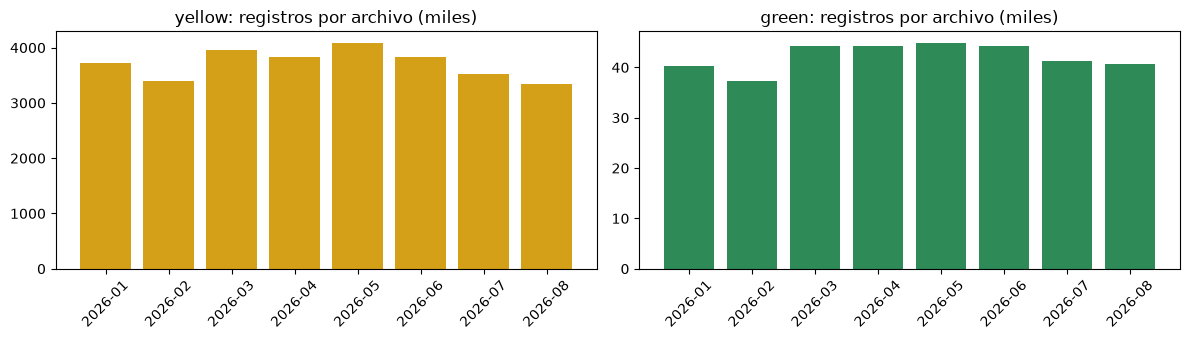

In [4]:
df = con.sql(q["registros_por_archivo"].sql).df()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, taxi, color in zip(axes, ["yellow", "green"], ["#d4a017", "#2e8b57"]):
    d = df[df.taxi == taxi]
    ax.bar(d.mes, d.filas / 1e3, color=color)
    ax.set_title(f"{taxi}: registros por archivo (miles)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

## 3.2 Registros totales

In [5]:
run("registros_totales")

Objetivo: 3.2 Total de registros por tipo de taxi leyendo los archivos
Fuente:   data/raw/yellow/2026/*.parquet y data/raw/green/2026/*.parquet

SELECT 'yellow' AS taxi, COUNT(*) AS registros FROM read_parquet('data/raw/yellow/2026/*.parquet')
UNION ALL
SELECT 'green', COUNT(*) FROM read_parquet('data/raw/green/2026/*.parquet')
UNION ALL
SELECT 'total', COUNT(*) FROM read_parquet('data/raw/*/2026/*.parquet', union_by_name = true);


,taxi,registros
0,yellow,29703355
1,green,337114
2,total,30040469


## 3.3 / 3.4 Columnas y tipos de datos

In [6]:
run("columnas_y_tipos")

Objetivo: 3.3 y 3.4 Columnas y tipos de datos de cada tipo de taxi (lado a lado)
Fuente:   data/raw/yellow/2026/*.parquet y data/raw/green/2026/*.parquet

WITH y AS (
    SELECT column_name, column_type
    FROM (DESCRIBE SELECT * FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true))
), g AS (
    SELECT column_name, column_type
    FROM (DESCRIBE SELECT * FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true))
)
SELECT
    COALESCE(y.column_name, g.column_name) AS columna,
    y.column_type                          AS tipo_yellow,
    g.column_type                          AS tipo_green
FROM y FULL OUTER JOIN g USING (column_name)
ORDER BY (y.column_name IS NULL), (g.column_name IS NULL), columna;


,columna,tipo_yellow,tipo_green
0,DOLocationID,INTEGER,INTEGER
1,PULocationID,INTEGER,INTEGER
2,RatecodeID,BIGINT,BIGINT
3,VendorID,INTEGER,INTEGER
4,cbd_congestion_fee,DOUBLE,DOUBLE
5,congestion_surcharge,DOUBLE,DOUBLE
6,extra,DOUBLE,DOUBLE
7,fare_amount,DOUBLE,DOUBLE
8,improvement_surcharge,DOUBLE,DOUBLE
9,mta_tax,DOUBLE,DOUBLE


## Deriva de esquema entre archivos

In [7]:
run("deriva_de_esquema")

Objetivo: 3.4/3.6 Columnas que NO estan en todos los archivos (cambios de esquema entre meses)
Fuente:   data/raw/*/2026/*.parquet (esquema fisico de cada archivo)

WITH s AS (
    SELECT regexp_extract(file_name, '(yellow|green)', 1)  AS taxi,
           regexp_extract(file_name, '(\d{4}-\d{2})', 1)   AS mes,
           name                                            AS columna
    FROM parquet_schema('data/raw/*/2026/*.parquet')
    WHERE name NOT IN ('schema', 'duckdb_schema')
), archivos AS (
    SELECT taxi, COUNT(DISTINCT mes) AS total FROM s GROUP BY taxi
)
SELECT s.taxi, s.columna, COUNT(*) AS archivos_con_columna, a.total AS archivos_totales,
       MIN(s.mes) AS desde, MAX(s.mes) AS hasta
FROM s JOIN archivos a USING (taxi)
GROUP BY ALL
HAVING COUNT(*) < a.total
ORDER BY s.taxi, s.columna;


,taxi,columna,archivos_con_columna,archivos_totales,desde,hasta
0,green,request_source,3,8,2026-06,2026-08
1,yellow,request_source,3,8,2026-06,2026-08


## Efecto de `union_by_name`

In [8]:
run("efecto_union_by_name")

Objetivo: 3.6 Mostrar que sin union_by_name DuckDB descarta columnas en silencio
Fuente:   data/raw/yellow/2026/*.parquet

SELECT 'sin union_by_name' AS lectura,
       COUNT(*) AS columnas,
       BOOL_OR(column_name = 'request_source') AS incluye_request_source
FROM (DESCRIBE SELECT * FROM read_parquet('data/raw/yellow/2026/*.parquet'))
UNION ALL
SELECT 'con union_by_name', COUNT(*), BOOL_OR(column_name = 'request_source')
FROM (DESCRIBE SELECT * FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true));


,lectura,columnas,incluye_request_source
0,sin union_by_name,20,False
1,con union_by_name,21,True


## 3.5 Muestra de registros — yellow

In [9]:
run("muestra_yellow")

Objetivo: 3.5 Muestra aleatoria reproducible de viajes amarillos
Fuente:   data/raw/yellow/2026/*.parquet

SELECT tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance,
       PULocationID, DOLocationID, payment_type, fare_amount, tip_amount, total_amount,
       cbd_congestion_fee, request_source
FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
USING SAMPLE reservoir(8 ROWS) REPEATABLE (42);


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,cbd_congestion_fee,request_source
0,2026-01-01 00:24:41,2026-01-01 00:36:23,1,4.80,87,162,2,21.2,0.00,26.95,0.75,None
1,2026-01-01 02:08:35,2026-01-01 02:21:22,2,2.30,90,229,1,14.2,1.40,21.35,0.75,None
2,2026-01-01 02:01:56,2026-01-01 02:17:20,1,5.69,80,95,2,26.1,0.00,28.60,0.00,None
3,2026-01-01 04:36:54,2026-01-01 04:48:35,1,2.56,68,79,1,14.2,3.99,23.94,0.75,None
4,2026-01-01 09:37:17,2026-01-01 09:42:10,1,0.80,239,142,1,6.5,2.10,12.60,0.00,None
5,2026-01-01 11:29:34,2026-01-01 11:36:19,1,0.74,161,163,1,7.9,3.16,15.81,0.75,None
6,2026-01-01 11:42:55,2026-01-01 11:49:37,1,1.03,163,186,2,7.9,0.00,12.65,0.75,None
7,2026-01-01 13:36:51,2026-01-01 13:45:33,1,0.80,186,48,2,8.6,0.00,13.35,0.75,None


## 3.5 Muestra de registros — green

In [10]:
run("muestra_green")

Objetivo: 3.5 Muestra aleatoria reproducible de viajes verdes
Fuente:   data/raw/green/2026/*.parquet

SELECT lpep_pickup_datetime, lpep_dropoff_datetime, passenger_count, trip_distance,
       PULocationID, DOLocationID, payment_type, trip_type, fare_amount, tip_amount,
       total_amount, ehail_fee
FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
USING SAMPLE reservoir(8 ROWS) REPEATABLE (42);


,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,trip_type,fare_amount,tip_amount,total_amount,ehail_fee
0,2026-01-03 17:06:05,2026-01-03 17:11:27,1,1.15,74,41,1,1,7.2,4.00,12.70,NaN
1,2026-01-11 22:28:43,2026-01-11 22:32:53,2,0.00,74,42,1,1,5.8,1.66,9.96,NaN
2,2026-01-13 18:36:59,2026-01-13 18:41:12,1,1.08,43,238,1,1,7.2,3.49,17.44,NaN
3,2026-01-16 15:15:45,2026-01-16 15:43:34,1,9.39,244,233,2,1,38.0,0.00,43.00,NaN
4,2026-01-20 15:12:55,2026-01-20 15:24:05,1,1.40,82,82,2,1,11.4,0.00,12.90,NaN
5,2026-01-23 10:19:05,2026-01-23 10:37:24,1,3.02,74,238,1,1,18.4,4.53,27.18,NaN
6,2026-01-24 15:40:48,2026-01-24 15:52:07,1,1.05,65,40,1,1,10.7,1.59,13.79,NaN
7,2026-01-30 00:16:28,2026-01-30 00:23:47,1,1.36,75,238,1,1,9.3,1.77,13.57,NaN


## 3.6 Perfil de columnas — yellow

In [11]:
run("perfil_yellow")

Objetivo: 3.6 Perfil estadistico de todas las columnas (min, max, nulos, cardinalidad)
Fuente:   data/raw/yellow/2026/*.parquet

SELECT column_name, column_type, min, max, approx_unique, null_percentage
FROM (SUMMARIZE SELECT * FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true));


,column_name,column_type,min,max,approx_unique,null_percentage
0,VendorID,INTEGER,1,7,4,0.00
1,tpep_pickup_datetime,TIMESTAMP,2001-01-01 09:23:58,2026-08-31 23:59:59,16867928,0.00
2,tpep_dropoff_datetime,TIMESTAMP,2001-01-01 16:09:38,2026-09-01 20:16:00,16587125,0.00
3,passenger_count,BIGINT,0,9,11,25.98
4,trip_distance,DOUBLE,0.0,328522.2,7217,0.00
5,RatecodeID,BIGINT,1,99,7,25.98
6,store_and_fwd_flag,VARCHAR,N,Y,2,25.98
7,PULocationID,INTEGER,1,265,290,0.00
8,DOLocationID,INTEGER,1,265,298,0.00
9,payment_type,BIGINT,0,5,6,0.00


## 3.6 Perfil de columnas — green

In [12]:
run("perfil_green")

Objetivo: 3.6 Perfil estadistico de todas las columnas (min, max, nulos, cardinalidad)
Fuente:   data/raw/green/2026/*.parquet

SELECT column_name, column_type, min, max, approx_unique, null_percentage
FROM (SUMMARIZE SELECT * FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true));


,column_name,column_type,min,max,approx_unique,null_percentage
0,VendorID,INTEGER,1,6,3,0.00
1,lpep_pickup_datetime,TIMESTAMP,2008-12-31 17:35:31,2026-08-31 23:58:28,332702,0.00
2,lpep_dropoff_datetime,TIMESTAMP,2008-12-31 23:16:26,2026-09-02 09:39:37,396286,0.00
3,store_and_fwd_flag,VARCHAR,N,Y,2,14.47
4,RatecodeID,BIGINT,1,99,7,14.47
5,PULocationID,INTEGER,1,265,263,0.00
6,DOLocationID,INTEGER,1,265,266,0.00
7,passenger_count,BIGINT,0,9,11,14.47
8,trip_distance,DOUBLE,0.0,179830.92,2472,0.00
9,fare_amount,DOUBLE,-500.0,1676.7,4808,0.00


## 3.6 Calidad: fechas y duraciones

In [13]:
run("calidad_fechas")

Objetivo: 3.6 Viajes con fechas fuera del mes del archivo o con duracion invalida
Fuente:   data/raw/*/2026/*.parquet (via vista trips de sql/00_vistas.sql)

SELECT
    taxi_type,
    COUNT(*)                                                          AS registros,
    MIN(pickup_at)                                                    AS pickup_min,
    MAX(pickup_at)                                                    AS pickup_max,
    COUNT(*) FILTER (WHERE year(pickup_at) <> source_year
                        OR month(pickup_at) <> source_month)          AS fuera_de_su_mes,
    COUNT(*) FILTER (WHERE dropoff_at <= pickup_at)                   AS duracion_cero_o_negativa,
    COUNT(*) FILTER (WHERE dropoff_at > pickup_at + INTERVAL 6 HOUR)  AS duracion_mayor_6h
FROM trips
WHERE source_year = 2026
GROUP BY taxi_type;


,taxi_type,registros,pickup_min,pickup_max,fuera_de_su_mes,duracion_cero_o_negativa,duracion_mayor_6h
0,green,337114,2008-12-31 17:35:31,2026-08-31 23:58:28,98,234,1104
1,yellow,29703355,2001-01-01 09:23:58,2026-08-31 23:59:59,146,371683,7315


## 3.6 Calidad: distancias y montos

In [14]:
run("calidad_valores")

Objetivo: 3.6 Distancias y montos imposibles o sospechosos
Fuente:   data/raw/*/2026/*.parquet (via vista trips)

SELECT
    taxi_type,
    COUNT(*) FILTER (WHERE trip_distance = 0)          AS distancia_cero,
    COUNT(*) FILTER (WHERE trip_distance > 100)        AS distancia_mayor_100mi,
    MAX(trip_distance)                                 AS distancia_max,
    COUNT(*) FILTER (WHERE fare_amount < 0)            AS tarifa_negativa,
    COUNT(*) FILTER (WHERE total_amount < 0)           AS total_negativo,
    MIN(total_amount)                                  AS total_min,
    COUNT(*) FILTER (WHERE total_amount > 1000)        AS total_mayor_1000,
    MAX(total_amount)                                  AS total_max,
    COUNT(*) FILTER (WHERE passenger_count = 0)        AS pasajeros_cero,
    COUNT(*) FILTER (WHERE pu_location_id IN (264, 265)) AS zona_origen_desconocida
FROM trips
WHERE source_year = 2026
GROUP BY taxi_type;


,taxi_type,distancia_cero,distancia_mayor_100mi,distancia_max,tarifa_negativa,total_negativo,total_min,total_mayor_1000,total_max,pasajeros_cero,zona_origen_desconocida
0,green,12212,72,179830.92,999,1023,-501.5,1,1678.2,4527,1131
1,yellow,952231,1223,328522.20,157364,161835,-2560.2,49,7053.5,91359,49676


## 3.6 Calidad: nulos por tipo de pago

In [15]:
run("calidad_nulos_por_tipo_pago")

Objetivo: 3.6 Ver si los nulos se concentran en algun tipo de pago
Fuente:   data/raw/*/2026/*.parquet (via vista trips)

SELECT
    taxi_type,
    payment_type,
    COUNT(*)                                                  AS registros,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY taxi_type), 2) AS pct,
    ROUND(100.0 * AVG((passenger_count IS NULL)::INT), 1)     AS pct_pasajeros_nulo,
    ROUND(100.0 * AVG((ratecode_id IS NULL)::INT), 1)         AS pct_ratecode_nulo,
    ROUND(100.0 * AVG((congestion_surcharge IS NULL)::INT), 1) AS pct_congestion_nulo,
    ROUND(AVG(tip_amount), 2)                                 AS propina_prom
FROM trips
WHERE source_year = 2026
GROUP BY taxi_type, payment_type
ORDER BY taxi_type DESC, payment_type NULLS LAST;


,taxi_type,payment_type,registros,pct,pct_pasajeros_nulo,pct_ratecode_nulo,pct_congestion_nulo,propina_prom
0,yellow,0,7716688,25.98,100.0,100.0,100.0,0.40
1,yellow,1,18941008,63.77,0.0,0.0,0.0,4.28
2,yellow,2,2708031,9.12,0.0,0.0,0.0,0.00
3,yellow,3,98138,0.33,0.0,0.0,0.0,0.00
4,yellow,4,239488,0.81,0.0,0.0,0.0,0.00
5,yellow,5,2,0.00,0.0,0.0,0.0,0.00
6,green,1,219980,65.25,0.0,0.0,0.0,3.84
7,green,2,65921,19.55,0.0,0.0,0.0,0.00
8,green,3,1688,0.50,0.0,0.0,0.0,0.00
9,green,4,750,0.22,0.0,0.0,0.0,0.00


## 3.6 Calidad: códigos fuera de diccionario

In [16]:
run("calidad_codigos_fuera_de_diccionario")

Objetivo: 3.6 Valores de codigos no definidos en el diccionario de datos de la TLC
Fuente:   data/raw/*/2026/*.parquet (via vista trips)

SELECT
    taxi_type,
    COUNT(*) FILTER (WHERE ratecode_id = 99)                         AS ratecode_99,
    COUNT(*) FILTER (WHERE ratecode_id NOT IN (1,2,3,4,5,6,99))      AS ratecode_otro,
    COUNT(*) FILTER (WHERE vendor_id NOT IN (1,2,6,7))               AS vendor_desconocido,
    COUNT(*) FILTER (WHERE payment_type NOT IN (0,1,2,3,4,5,6))      AS payment_otro,
    COUNT(*) FILTER (WHERE taxi_type = 'green' AND trip_type IS NULL AND payment_type IS NOT NULL) AS trip_type_nulo,
    COUNT(ehail_fee)                                                 AS ehail_fee_no_nulo
FROM trips
WHERE source_year = 2026
GROUP BY taxi_type;


,taxi_type,ratecode_99,ratecode_otro,vendor_desconocido,payment_otro,trip_type_nulo,ehail_fee_no_nulo
0,yellow,769693,0,0,0,0,0
1,green,2,0,0,0,2,0


## 3.6 Calidad: total vs. componentes

In [17]:
run("calidad_total_vs_componentes")

Objetivo: 3.6 Verificar si total_amount coincide con la suma de sus componentes
Fuente:   data/raw/yellow/2026/*.parquet (via vista trips)

SELECT
    payment_type,
    ROUND(total_amount - (fare_amount + extra + mta_tax + tip_amount + tolls_amount
          + improvement_surcharge + COALESCE(congestion_surcharge, 0)
          + COALESCE(airport_fee, 0) + COALESCE(cbd_congestion_fee, 0)), 2) AS diferencia,
    COUNT(*) AS registros
FROM trips
WHERE source_year = 2026 AND taxi_type = 'yellow'
GROUP BY 1, 2
QUALIFY ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) <= 10
ORDER BY registros DESC;


,payment_type,diferencia,registros
0,1,0.00,15469459
1,0,2.50,4747991
2,1,-3.25,2440215
3,2,0.00,2269576
4,0,0.00,812122
5,1,-2.50,646881
6,2,-3.25,294687
7,4,0.00,209877
8,0,5.50,112169
9,0,3.50,86542


## 3.6 Calidad: duplicados

In [18]:
run("duplicados_exactos")

Objetivo: 3.6 Registros repetidos exactamente (todas las columnas iguales)
Fuente:   data/raw/*/2026/*.parquet (via vista trips)

SELECT taxi_type,
       COUNT(*)                                       AS registros,
       COUNT(*) - COUNT(DISTINCT (vendor_id, pickup_at, dropoff_at, passenger_count,
            trip_distance, pu_location_id, do_location_id, payment_type,
            fare_amount, tip_amount, total_amount))   AS duplicados
FROM trips
WHERE source_year = 2026
GROUP BY taxi_type;


,taxi_type,registros,duplicados
0,green,337114,0
1,yellow,29703355,7


## Impacto de la vista `trips_clean`

In [19]:
run("impacto_limpieza")

Objetivo: 3.6 Cuantos registros sobreviven a los filtros de la vista trips_clean
Fuente:   data/raw/*/2026/*.parquet (vistas trips y trips_clean)

SELECT t.taxi_type,
       t.registros                                         AS crudos,
       c.registros                                         AS limpios,
       t.registros - c.registros                           AS descartados,
       ROUND(100.0 * (t.registros - c.registros) / t.registros, 2) AS pct_descartado
FROM (SELECT taxi_type, COUNT(*) AS registros FROM trips WHERE source_year = 2026 GROUP BY 1) t
JOIN (SELECT taxi_type, COUNT(*) AS registros FROM trips_clean WHERE source_year = 2026 GROUP BY 1) c
  USING (taxi_type)
ORDER BY crudos DESC;


,taxi_type,crudos,limpios,descartados,pct_descartado
0,yellow,29703355,28236044,1467311,4.94
1,green,337114,323096,14018,4.16


## 3.9 Consultar Parquet directamente

`COUNT(*)` sobre 30 millones de filas tarda décimas de segundo porque DuckDB lo responde con los metadatos del *footer* de cada archivo; las consultas que filtran o agregan leen solo las columnas que usan. Ver la discusión completa en `docs/03_consultas_directas.md`.